# Lab Assignment 3: Medical Health Data Analysis

This notebook covers Data Acquisition, Cleaning, Preprocessing, and Analysis on Tabular, Textual, Image, and Signal medical data.

## Part A: Tabular Data (Pima Indians Diabetes Dataset)

**Dataset**: Pima Indians Diabetes Database

In [1]:
!pip install pandas numpy matplotlib seaborn scipy statsmodels scikit-learn nltk torchvision Pillow wfdb

  Using cached patsy-1.0.3-py2.py3-none-any.whl.metadata (3.7 kB)
  Using cached formulaic-1.2.2-py3-none-any.whl.metadata (7.0 kB)
  Using cached interface_meta-2.0.1-py3-none-any.whl.metadata (6.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 2.3 MB/s  0:00:04m 2.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 1.8 MB/s  0:00:01m 1.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.3/127.3 MB 2.8 MB/s  0:01:05 eta 0:00:010:00:02
Using cached formulaic-1.2.2-py3-none-any.whl (118 kB)
Using cached interface_meta-2.0.1-py3-none-any.whl (15 kB)
Using cached patsy-1.0.3-py2.py3-none-any.whl (233 kB)
  Attempting uninstall: torch
    Found existing installation: torch 2.10.0
    Uninstalling torch-2.10.0:━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/6 [torch]
      Successfully uninstalled torch-2.10.07m╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/6 [torch]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [statsmodels] 5/6 [statsmodels]laic]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 1. Data Acquisition
df_diabetes = pd.read_csv('datasets/A/diabetes.csv')
df_diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# 2. Data Cleaning: Healthcare-specific concerns
# Replace 0s with NaN for clinical variables where 0 is physiologically implausible
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_diabetes[cols_with_zeros] = df_diabetes[cols_with_zeros].replace(0, np.nan)

# Impute missing values using the median
df_diabetes.fillna(df_diabetes.median(), inplace=True)
print(df_diabetes.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


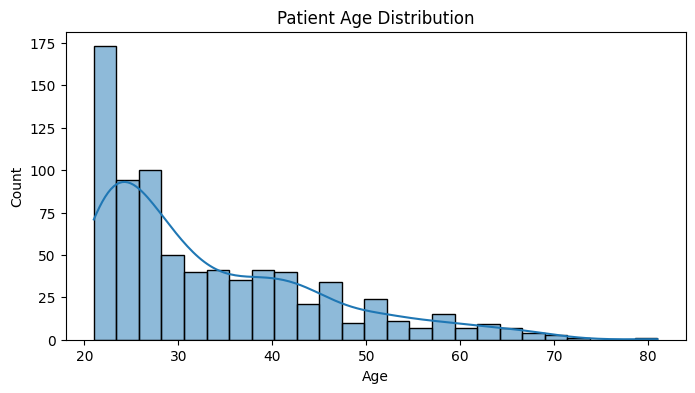

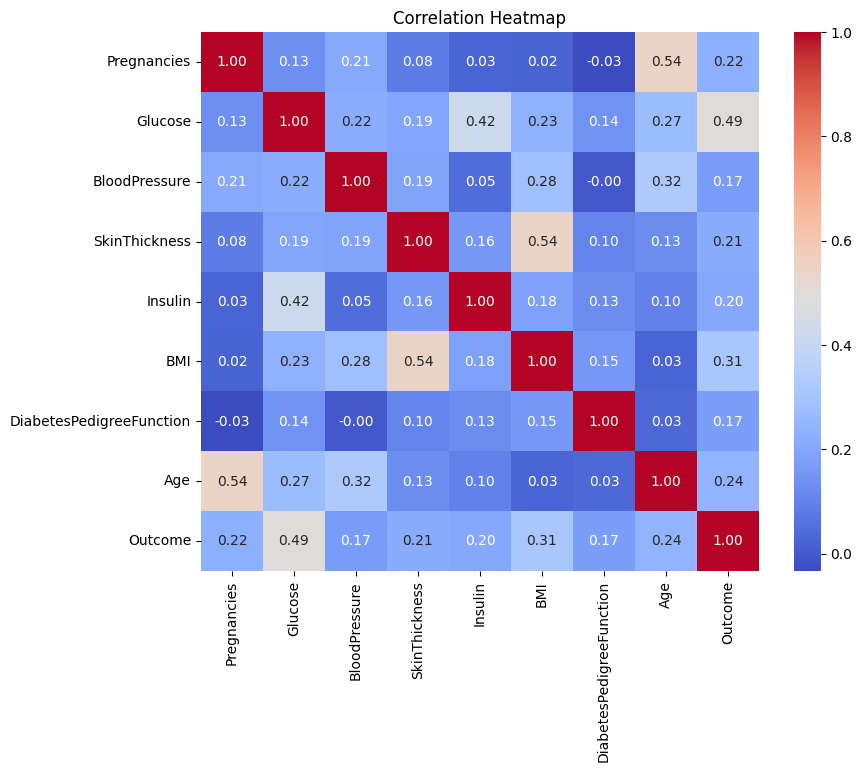

In [4]:
# 3. Exploratory Data Analysis (EDA)
plt.figure(figsize=(8, 4))
sns.histplot(df_diabetes['Age'], kde=True, bins=25)
plt.title('Patient Age Distribution')
plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(df_diabetes.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [5]:
# 4. Statistical Testing

# a. Hypothesis Testing (Two-sample T-Test)
diabetic_glucose = df_diabetes[df_diabetes['Outcome'] == 1]['Glucose']
normal_glucose = df_diabetes[df_diabetes['Outcome'] == 0]['Glucose']
t_stat, p_val = stats.ttest_ind(diabetic_glucose, normal_glucose)
print(f'T-test p-value (Glucose vs Outcome): {p_val}')

# b. Chi-Square Test (Categorical Association)
df_diabetes['Age_Group'] = pd.cut(df_diabetes['Age'], bins=[20, 30, 40, 50, 100], labels=['20-30', '30-40', '40-50', '50+'])
contingency_table = pd.crosstab(df_diabetes['Age_Group'], df_diabetes['Outcome'])
chi2, p_chi, dof, _ = stats.chi2_contingency(contingency_table)
print(f'Chi-Square p-value (Age_Group vs Outcome): {p_chi}')

# c. ANOVA Test (Difference in BMI across Age Groups)
model = ols('BMI ~ C(Age_Group)', data=df_diabetes).fit()
anova_results = sm.stats.anova_lm(model, typ=2)
print('\nANOVA Results (BMI across Age Groups):')
print(anova_results)

T-test p-value (Glucose vs Outcome): 3.128719041842255e-48
Chi-Square p-value (Age_Group vs Outcome): 6.521685313585261e-16

ANOVA Results (BMI across Age Groups):
                    sum_sq     df         F    PR(>F)
C(Age_Group)    751.287136    3.0  5.389012  0.001129
Residual      35503.312030  764.0       NaN       NaN


## Part B: Textual Data (MTSamples Medical Transcriptions)

In [6]:
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords', quiet=True)

# 1. Data Acquisition
df_text = pd.read_csv('datasets/B/mtsamples.csv')
df_text.head(2)

,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."


In [7]:
# 2. Cleaning & PHI Removal
# In healthcare text, removing Protected Health Information (PHI) is critical for privacy.
def clean_medical_text(text):
    if not isinstance(text, str): 
        return ''
    # Redact simulated identifiers (SSN, phone numbers)
    text = re.sub(r'\b\d{3}-\d{2}-\d{4}\b', '[SSN]', text)
    text = re.sub(r'\b\d{3}-\d{3}-\d{4}\b', '[PHONE]', text)
    # Strip punctuation & normalize case
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    return text.lower()

df_text['cleaned_transcription'] = df_text['transcription'].apply(clean_medical_text)
print(df_text['cleaned_transcription'].iloc[0][:200])

subjective    this    year old white female presents with complaint of allergies   she used to have allergies when she lived in seattle but she thinks they are worse here   in the past  she has tried 


In [8]:
# 3. Preprocessing (Token Sequences & TF-IDF Vectorization)
stop_words = set(stopwords.words('english'))

# Tokenization
df_text['tokens'] = df_text['cleaned_transcription'].apply(lambda x: [w for w in x.split() if w not in stop_words])

# TF-IDF Feature Extraction
vectorizer = TfidfVectorizer(max_features=1000)
tfidf_matrix = vectorizer.fit_transform(df_text['cleaned_transcription'])
print(f'TF-IDF Matrix Shape: {tfidf_matrix.shape}')

TF-IDF Matrix Shape: (4999, 1000)


## Part C: Image Data (Chest X-Ray Pneumonia)

Preprocess chest radiographs into scaled tensors and apply medical-appropriate augmentations.

In [9]:
from PIL import Image
import torchvision.transforms as transforms

# 1. Preprocessing into Scaled Tensors
img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(), # Scales pixel intensities to [0, 1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load a sample image from Part C dataset
img_path = 'datasets/C/NORMAL/IM-0019-0001.jpeg'
img = Image.open(img_path).convert('RGB')
img_tensor = img_transform(img)
print(f'Transformed image tensor shape: {img_tensor.shape}')

Transformed image tensor shape: torch.Size([3, 224, 224])


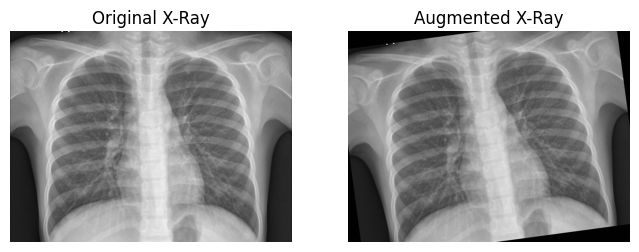

In [10]:
# 2. Data Augmentation
augment_transform = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1)
])

augmented_img = augment_transform(img)

# Display Original vs Augmented
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img)
axes[0].set_title('Original X-Ray')
axes[0].axis('off')

axes[1].imshow(augmented_img)
axes[1].set_title('Augmented X-Ray')
axes[1].axis('off')
plt.show()

## Part D: Signal Data (MIT-BIH Arrhythmia Database)

ECG acquisition, bandpass noise filtering, and signal windowing.

In [11]:
import wfdb
from scipy.signal import butter, filtfilt

# 1. Data Acquisition (Record 100)
record = wfdb.rdrecord('datasets/D/100', sampto=3000)
fs = record.fs
raw_ecg = record.p_signal[:, 0]
print(f'Sampling frequency: {fs} Hz, Total samples loaded: {len(raw_ecg)}')

Sampling frequency: 360 Hz, Total samples loaded: 3000


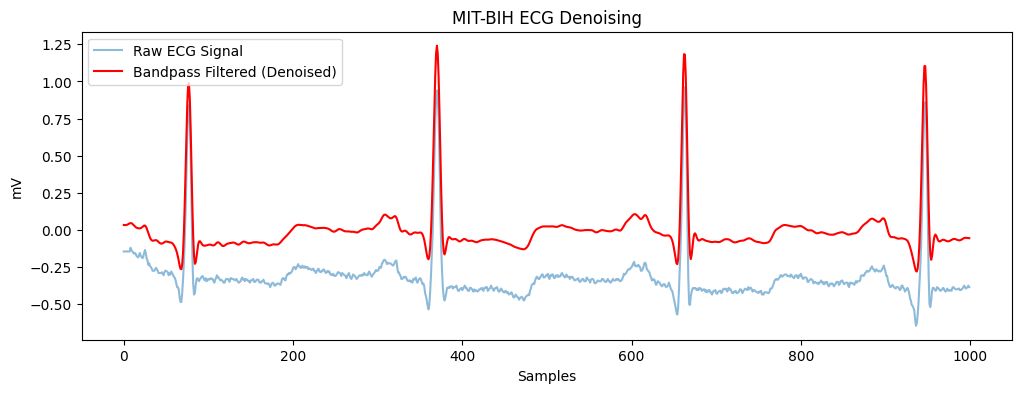

In [12]:
# 2. Preprocessing: Noise Removal
# Bandpass filter (0.5 Hz - 40 Hz) removes baseline wander and high frequency muscle artifacts
def bandpass_filter(data, lowcut=0.5, highcut=40.0, fs=360, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

filtered_ecg = bandpass_filter(raw_ecg, fs=fs)

# EDA: Plotting Raw vs Filtered ECG
plt.figure(figsize=(12, 4))
plt.plot(raw_ecg[:1000], label='Raw ECG Signal', alpha=0.5)
plt.plot(filtered_ecg[:1000], label='Bandpass Filtered (Denoised)', color='red')
plt.title('MIT-BIH ECG Denoising')
plt.xlabel('Samples')
plt.ylabel('mV')
plt.legend()
plt.show()

In [13]:
# 3. Preprocessing into Model-Ready Format (Signal Windowing)
# Window continuous signals into fixed-length windows (e.g., 1-second segments)
window_size = int(1.0 * fs)
signal_windows = np.array([filtered_ecg[i:i + window_size] 
                           for i in range(0, len(filtered_ecg) - window_size, window_size)])

print(f'Windowed Signal Shape: {signal_windows.shape} (Windows, Samples per Window)')

Windowed Signal Shape: (8, 360) (Windows, Samples per Window)
